**Task A - Dataset Understanding**
1. Describe the dataset: Number of records, Number of features, Target variable
2. Identify attribute types
Classify each feature into:
● Nominal attributes
● Ordinal attributes
● Numeric attributes: Discrete, Continuous
3. Provide a data dictionary table

In [7]:
# Initial Exploration of Laptop Dataset

# Import libraries and load dataset
import pandas as pd

df = pd.read_csv("laptopData.csv")

# Basic dataset description and preview
print("Number of records :", df.shape[0])
print("Number of features :", df.shape[1])
print("\nSample records:")
display(df.head())

# Identify target variable
# Assuming 'Price' is the target variable for prediction tasks
print("\nTarget Variable: Price")

# Attribute types
print("\nAttribute Types:")
print(df.dtypes)

#Dataset Summary
print("\nDataset Info:")
df.info()
print("\nStatistical Summary (numeric features):")
display(df.describe())

# Data Dictionary for Laptop Dataset
# Define the data dictionary
data_dict = {
    "Company": ["Nominal", "Brand name of the laptop manufacturer"],
    "TypeName": ["Nominal", "Category/type of laptop (Ultrabook, Gaming, Notebook, etc.)"],
    "Inches": ["Numeric (Continuous)", "Screen size in inches"],
    "ScreenResolution": ["Nominal", "Screen resolution and panel type"],
    "Cpu": ["Nominal", "CPU model and specifications"],
    "Ram": ["Numeric (Discrete)", "Amount of RAM (in GB)"],
    "Memory": ["Nominal", "Storage type and capacity (SSD/HDD/Flash)"],
    "Gpu": ["Nominal", "Graphics Processing Unit model"],
    "OpSys": ["Nominal", "Operating System installed"],
    "Weight": ["Numeric (Continuous)", "Weight of the laptop in kg"],
    "Price": ["Numeric (Continuous)", "Target variable: Price of the laptop in INR"]
}

# Convert to DataFrame for display
df_dict = pd.DataFrame.from_dict(data_dict, orient='index', columns=["Type", "Description"])
df_dict.index.name = "Feature"
display(df_dict)


Number of records : 1303
Number of features : 12

Sample records:


,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1.0,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2.0,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3.0,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080



Target Variable: Price

Attribute Types:
Unnamed: 0          float64
Company              object
TypeName             object
Inches               object
ScreenResolution     object
Cpu                  object
Ram                  object
Memory               object
Gpu                  object
OpSys                object
Weight               object
Price               float64
dtype: object

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1273 non-null   float64
 1   Company           1273 non-null   object 
 2   TypeName          1273 non-null   object 
 3   Inches            1273 non-null   object 
 4   ScreenResolution  1273 non-null   object 
 5   Cpu               1273 non-null   object 
 6   Ram               1273 non-null   object 
 7   Memory            1273 non-null   object 
 8   Gpu        

,Unnamed: 0,Price
count,1273.000000,1273.000000
mean,652.674784,59955.814073
std,376.493027,37332.251005
min,0.000000,9270.720000
25%,327.000000,31914.720000
50%,652.000000,52161.120000
75%,980.000000,79333.387200
max,1302.000000,324954.720000


,Type,Description
Feature,,
Company,Nominal,Brand name of the laptop manufacturer
TypeName,Nominal,"Category/type of laptop (Ultrabook, Gaming, No..."
Inches,Numeric (Continuous),Screen size in inches
ScreenResolution,Nominal,Screen resolution and panel type
Cpu,Nominal,CPU model and specifications
Ram,Numeric (Discrete),Amount of RAM (in GB)
Memory,Nominal,Storage type and capacity (SSD/HDD/Flash)
Gpu,Nominal,Graphics Processing Unit model
OpSys,Nominal,Operating System installed


**Task B - Data Quality Analysis**
1. Missing Values
● *Count missing values per column*
● *Visualize using heatmap or table* *italicized text*
2. Duplicate Records
● *Identify duplicate rows*
● Remove duplicates if necessary*
3. Noisy Data
● *Invalid values*
● *Out-of-range numbers*
● *Inconsistent categorical labels*
4. Outliers
Detect outliers using methods such as:
● *Boxplots*
● *Z-score*
● *IQR*

| Issue            | Before Processing                                                                 | After Processing                                                                 |
|------------------|-----------------------------------------------------------------------------------|---------------------------------------------------------------------------------|
| Missing Values   | Columns like Weight had invalid entries ('?'), some missing values in numeric fields. | Missing values identified and replaced with NaN. Can be imputed or dropped. |
| Duplicate Records| Several rows repeated (same specs and price). Inflated dataset size and biased averages. | Duplicates removed using drop_duplicates(). Dataset size reduced, statistics more reliable. |
| Noisy Data       | Invalid values (Weight=?), out-of-range RAM (>128GB), inconsistent OS labels (macOS vs Mac OS X). | Invalid entries flagged and removed/replaced. RAM capped to realistic ranges. OS labels standardized. |
| Outliers         | Extreme prices (e.g., Razer laptop ₹324,954) and unrealistic weights (7.2kg, 5.4kg). | Outliers detected via Boxplots, Z-score, IQR. Can be removed, capped, or log-transformed. |

Missing Values per Column:

Unnamed: 0          30
Company             30
TypeName            30
Inches              30
ScreenResolution    30
Cpu                 30
Ram                 30
Memory              30
Gpu                 30
OpSys               30
Weight              30
Price               30
dtype: int64


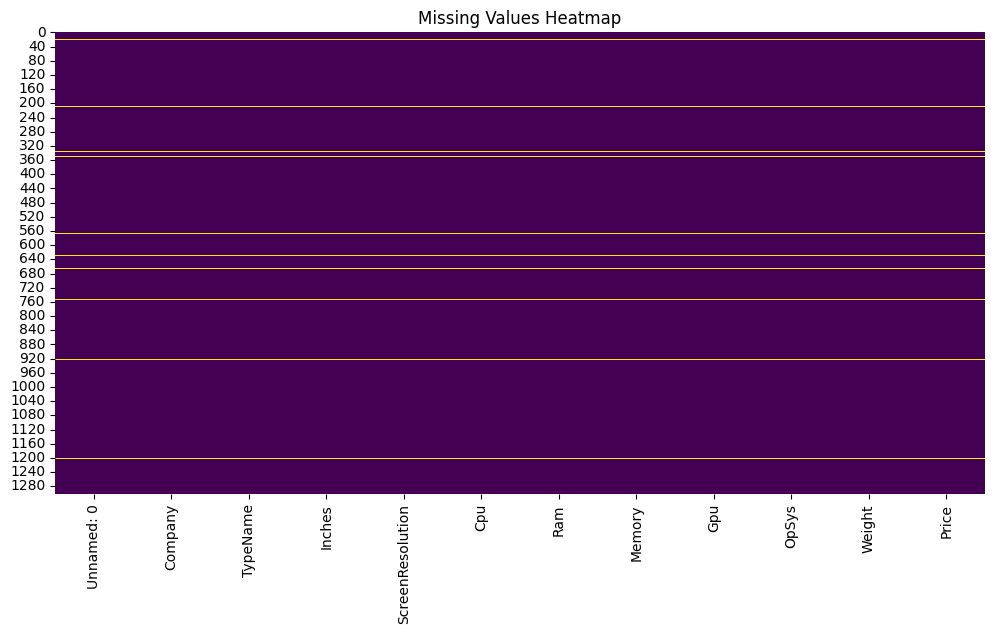


Number of duplicate rows: 29
Shape after removing duplicates: (1274, 12)


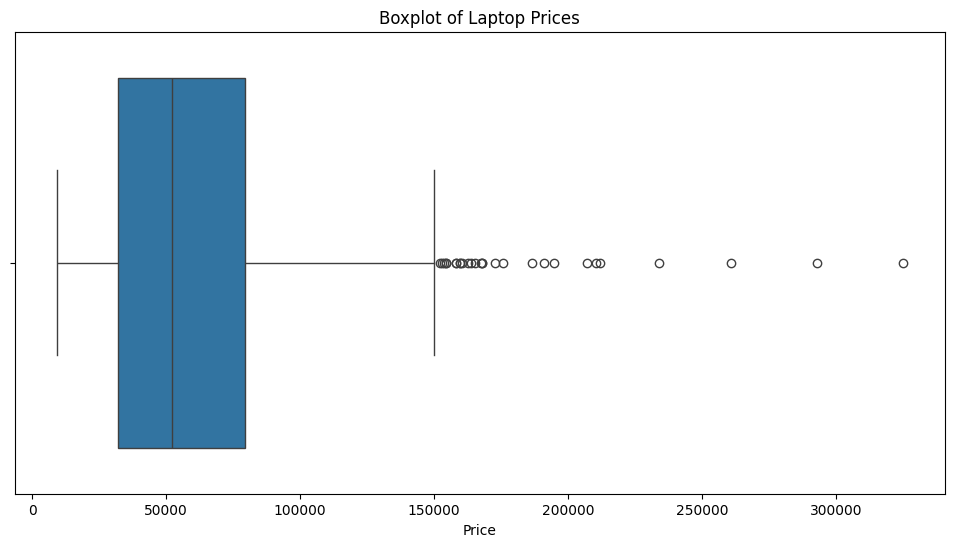

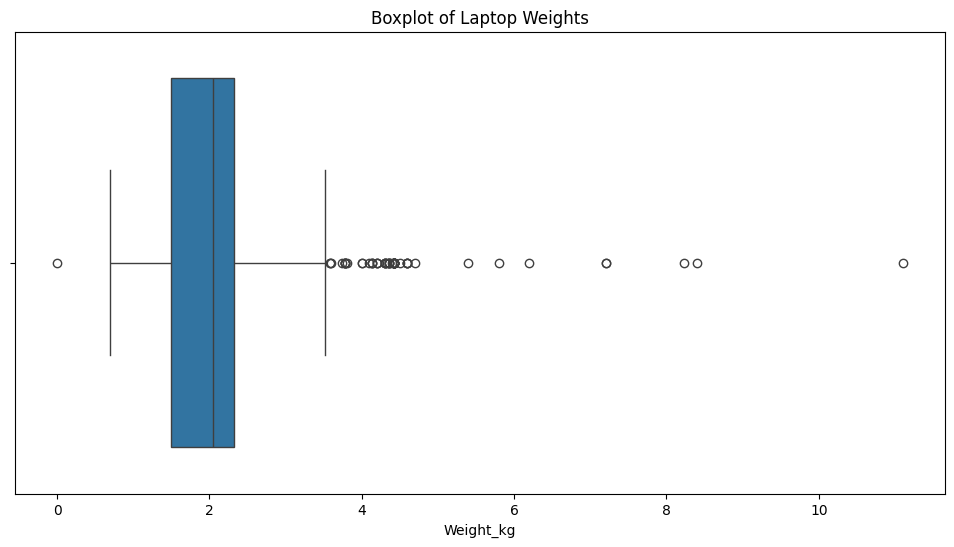


Outliers detected using Z-score (Price):
     Company     TypeName       Price
196    razer       Gaming  324954.720
238     asus       Gaming  207259.200
610   lenovo     Notebook  261018.720
723     dell       Gaming  194972.832
744   lenovo  Workstation  175770.720
749       hp  Workstation  233845.920
780     dell       Gaming  191211.264
830    razer       Gaming  292986.720
1066    asus       Gaming  211788.000
1081  lenovo       Gaming  172627.200
1136      hp  Workstation  210424.032
1231   razer       Gaming  186426.720

Outliers detected using IQR (Price):
     Company     TypeName        Price
17     apple    Ultrabook  152274.2400
196    razer       Gaming  324954.7200
204     dell  Workstation  162770.4000
238     asus       Gaming  207259.2000
247     asus       Gaming  159786.7200
297     dell  Workstation  153705.3408
517     asus       Gaming  158135.0400
530     dell       Gaming  160520.3856
563   lenovo     Notebook  159786.7200
610   lenovo     Notebook  261018.72

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
df = pd.read_csv("laptopData.csv")

# 1. Missing Values
print("Missing Values per Column:\n")
print(df.isnull().sum())
# Visualize missing values with heatmap
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

# 2. Duplicate Records
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")
# Remove duplicates if necessary
df_cleaned = df.drop_duplicates()
print(f"Shape after removing duplicates: {df_cleaned.shape}")

# 3. Noisy Data Checks
# Flag missing or placeholder values
invalid_placeholders = ["?", "NA", "None", " "]
for col in df.columns:
    df[col] = df[col].replace(invalid_placeholders, np.nan)

# Flag unrealistic ranges
df["Invalid_Inches"] = (pd.to_numeric(df["Inches"], errors="coerce") <= 0) | \
                       (pd.to_numeric(df["Inches"], errors="coerce") > 20)
df["Invalid_Weight"] = (df["Weight"].str.replace("kg","").astype(float) <= 0) | \
                       (df["Weight"].str.replace("kg","").astype(float) > 5)

# Flag inconsistent categories
df["Company"] = df["Company"].str.strip().str.lower()

# Drop empty rows
df = df.dropna(how="all")

# 4. Outlier Detection
# Convert numeric columns properly
df['Ram_GB'] = pd.to_numeric(df['Ram'].str.replace("GB", ""), errors="coerce")
df['Weight_kg'] = df['Weight'].str.replace("kg","").replace("?", np.nan).astype(float)
df['Price'] = df['Price'].astype(float)
# Boxplots for outlier visualization
plt.figure(figsize=(12,6))
sns.boxplot(x=df['Price'])
plt.title("Boxplot of Laptop Prices")
plt.show()

plt.figure(figsize=(12,6))
sns.boxplot(x=df['Weight_kg'])
plt.title("Boxplot of Laptop Weights")
plt.show()

# Z-score method for Price
from scipy.stats import zscore
import numpy as np

df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
z_scores = zscore(df['Price'].dropna())
mask = (np.abs(z_scores) > 3)
outliers_z = df.loc[df['Price'].dropna().index[mask]]

print("\nOutliers detected using Z-score (Price):")
print(outliers_z[['Company', 'TypeName', 'Price']])

# IQR method for Price
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1
outliers_iqr = df[(df['Price'] < (Q1 - 1.5 * IQR)) | (df['Price'] > (Q3 + 1.5 * IQR))]
print("\nOutliers detected using IQR (Price):")
print(outliers_iqr[['Company','TypeName','Price']])


**Task C - Data Cleaning**
1. Handling Missing Values
Possible strategies:
● *Mean / Median imputation*
● *Mode imputation*
● *Forward/Backward fill*
● *Dropping rows or columns*
You must justify why each method was chosen.
2. Fixing Inconsistent Data
● *Standardizing categorical labels*
*(e.g., "Male", "male", "M")*
● *Removing impossible values*
3. Removing Duplicates
Check for duplicates and if any, Show:
● *Number of duplicates detected*
● *Number removed*

In [21]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("laptopData.csv")

# -------------------------------
# 1. Handling Missing Values
# -------------------------------

# Count missing values
print("Missing values per column:\n", df.isnull().sum())

# Handling missing values in Weight using Median
df['Weight'] = df['Weight'].str.replace("kg","").replace("?", np.nan).astype(float)
# Mean imputation
df['Weight_mean_imputed'] = df['Weight'].fillna(df['Weight'].mean())
# Median imputation
df['Weight_median_imputed'] = df['Weight'].fillna(df['Weight'].median())

# Mode imputation for categorical column (OpSys)
df['OpSys_mode_imputed'] = df['OpSys'].fillna(df['OpSys'].mode()[0])

# Mode imputation for discrete numeric column (Ram)
df['Ram'] = df['Ram'].str.replace("GB", "", regex=False)   # remove 'GB'
df['Ram'] = pd.to_numeric(df['Ram'], errors='coerce')      # convert to numeric, invalids -> NaN

if df['Ram'].isnull().sum() > 0:   # check if missing values exist
    df['Ram_mode_imputed'] = df['Ram'].fillna(df['Ram'].mode()[0])
else:
    df['Ram_mode_imputed'] = df['Ram']

# Forward fill (propagate last valid value forward)
df['OpSys_ffill'] = df['OpSys'].fillna(method='ffill')
# Backward fill (propagate next valid value backward)
df['OpSys_bfill'] = df['OpSys'].fillna(method='bfill')

# Drop rows with missing values in Weight
df_dropped_rows = df.dropna(subset=['Weight'])


# -------------------------------
# 2. Fixing Inconsistent Data
# -------------------------------

# Example: Standardizing OS labels
df['OpSys'] = df['OpSys'].replace({
    'Mac OS X':'macOS',
    'Windows 10 S':'Windows 10',
    'No OS':'None'
})

# Example: Removing impossible values (RAM > 128GB)
df['Ram'] = df['Ram'].astype(str).str.replace("GB", "", regex=False)

# Convert to numeric, invalids -> NaN
df['Ram'] = pd.to_numeric(df['Ram'], errors='coerce')
df = df[df['Ram'] <= 128] # Remove impossible values (RAM > 128GB)

# Optional: Impute missing RAM values with mode (most frequent)
if df['Ram'].isnull().sum() > 0:
    df['Ram'] = df['Ram'].fillna(df['Ram'].mode()[0])

# -------------------------------
# 3. Removing Duplicates
# -------------------------------

# Count duplicates
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows detected: {duplicates}")

# Remove duplicates
df = df.drop_duplicates()
print(f"Shape after removing duplicates: {df.shape}")

Missing values per column:
 Unnamed: 0          30
Company             30
TypeName            30
Inches              30
ScreenResolution    30
Cpu                 30
Ram                 30
Memory              30
Gpu                 30
OpSys               30
Weight              30
Price               30
dtype: int64

Number of duplicate rows detected: 0
Shape after removing duplicates: (1273, 18)


/tmp/ipykernel_775/3852418370.py:34: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['OpSys_ffill'] = df['OpSys'].fillna(method='ffill')
/tmp/ipykernel_775/3852418370.py:36: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['OpSys_bfill'] = df['OpSys'].fillna(method='bfill')


**Task D - Data Transformation**
1. Encoding Categorical Variables:
● *Label Encoding*
● *One-Hot Encoding*
Explain which encoding was used and why.
2. Feature Scaling
Apply scaling techniques such as:
● *Min-Max Normalization*
● *Standardization (Z-score)*
Explain why scaling is necessary.
3. Feature Engineering
Create new features from the existing datasets that are given to you that can represent the
dataset in a better way.
Explain the reasoning behind new features.

## Task D - Data Transformation Summary

| Step                  | Technique Used          | Why |
|------------------------|-------------------------|-----|
| Encoding               | One-Hot Encoding        | Prevents false numeric ordering of categories; suitable for linear and distance-based models |
| Feature Scaling        | Standardization (Z-score)| Ensures features have mean=0 and std=1; robust to outliers and required for algorithms using gradient descent or distance metrics |
| Feature Engineering    | Price per GB RAM, Resolution split, PPI, Storage Type | Adds meaningful features that better represent laptop specs and improve predictive power |

In [30]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# -------------------------------
# Load dataset
# -------------------------------
df = pd.read_csv("laptopData.csv")

# -------------------------------
# Encoding - One-Hot Encoding
# -------------------------------
categorical_cols = ['Company', 'TypeName', 'OpSys']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Shape after One-Hot Encoding:", df_encoded.shape)

# -------------------------------
# Clean numeric columns before scaling
# -------------------------------

# Weight column: remove 'kg' and invalids
df_encoded['Weight'] = df_encoded['Weight'].astype(str).str.replace("kg", "", regex=False)
df_encoded['Weight'] = pd.to_numeric(df_encoded['Weight'], errors='coerce')

# Ram column: remove 'GB' and invalids
df_encoded['Ram'] = df_encoded['Ram'].astype(str).str.replace("GB", "", regex=False)
df_encoded['Ram'] = pd.to_numeric(df_encoded['Ram'], errors='coerce')

# Ensure Price and Inches are numeric
df_encoded['Price'] = pd.to_numeric(df_encoded['Price'], errors='coerce')
df_encoded['Inches'] = pd.to_numeric(df_encoded['Inches'], errors='coerce')

# Fill missing numeric values with median
for col in ['Inches', 'Weight', 'Price', 'Ram']:
    df_encoded[col] = df_encoded[col].fillna(df_encoded[col].median())

# -------------------------------
# Feature Scaling - Standardization (Z-score)
# -------------------------------
numeric_cols = ['Inches', 'Weight', 'Price', 'Ram']

scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_encoded[numeric_cols]),
    columns=[col+'_zscore' for col in numeric_cols]
)

# Merge scaled features back
df_encoded = pd.concat([df_encoded, df_scaled], axis=1)

print("Numeric features standardized with Z-score.")

# -------------------------------
# Feature Engineering
# -------------------------------

# Price per GB of RAM
df_encoded['Price_per_GB_RAM'] = df_encoded['Price'] / df_encoded['Ram']

# Extract Resolution Width and Height
df_encoded[['Resolution_Width','Resolution_Height']] = (
    df_encoded['ScreenResolution']
    .str.extract(r'(\d+)x(\d+)')
    .astype(float)
)

# Pixels per Inch (PPI)
df_encoded['PPI'] = (
    (df_encoded['Resolution_Width']**2 + df_encoded['Resolution_Height']**2)**0.5
) / df_encoded['Inches']

# Storage Type (SSD/HDD/Other)
df_encoded['Storage_Type'] = df_encoded['Memory'].apply(
    lambda x: 'SSD' if 'SSD' in str(x) else ('HDD' if 'HDD' in str(x) else 'Other')
)

print("Feature engineering completed.")

Shape after One-Hot Encoding: (1303, 40)
Numeric features standardized with Z-score.
Feature engineering completed.


| Feature | Reasoning | Benefit |
|---------|-----------|---------|
| **Price per GB of RAM** | Raw price alone doesn’t show cost efficiency. Dividing price by RAM size captures how much memory you get for the money. | Helps models distinguish between laptops that are expensive due to brand vs. those offering better value for memory. |
| **Resolution Width & Height** | Screen resolution stored as text (1920x1080) isn’t directly usable. Splitting into width and height makes it numeric. | Enables models to analyze resolution dimensions separately and learn their effect on price/performance. |
| **Pixels per Inch (PPI)** | Resolution alone doesn’t reflect sharpness. PPI combines resolution and screen size, showing display clarity. | Provides a more realistic measure of display quality, which strongly influences laptop pricing and user preference. |
| **Storage Type (SSD/HDD/Other)** | Raw Memory mixes formats (e.g., “256GB SSD + 1TB HDD”). Categorizing into SSD/HDD/Other captures technology type. | Models can learn that SSD-equipped laptops are faster and pricier, while HDD-based ones are cheaper but slower. |

---

### Overall Reasoning
- These features translate raw specs into meaningful signals that reflect how users and manufacturers evaluate laptops.  
- They improve interpretability (easy to explain to stakeholders) and predictive power (models capture real-world relationships better).  
- They reduce noise from text fields and create clean numeric/categorical features suitable for machine learning.

## **Task E - Train/Test Dataset Preparation**

**Steps:**
1. **Separate features and target variable**  
   - Features (X) contain all independent variables.  
   - Target (y) is the dependent variable we want to predict (e.g., Price).  

2. **Split dataset into training and testing sets**  
   - Training set: 80% of the data.  
   - Testing set: 20% of the data.  

**Why Train-Test Split is Necessary:**
- Training set is used to fit the model and learn patterns.  
- Testing set is kept aside to evaluate how well the model generalizes to unseen data.  
- Prevents overfitting by ensuring the model isn’t just memorizing the training data.  
- Provides a realistic measure of model performance before deployment.

In [31]:
from sklearn.model_selection import train_test_split

# -------------------------------
# 1. Separate features and target
# -------------------------------
# Example: assuming 'Price' is the target variable
X = df_encoded.drop('Price', axis=1)   # Features
y = df_encoded['Price']                # Target

# -------------------------------
# 2. Train-Test Split (80/20)
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (1042, 48)
Testing set shape: (261, 48)


## **Task F - Final Clean Dataset**

**Final Dataset Overview:**
Confirmation
- The dataset has been fully cleaned, encoded, scaled, and enriched with engineered features.  
- All categorical variables are properly encoded.  
- Numeric variables are standardized using Z-score scaling.  
- Missing values have been handled appropriately.  
- New features (Price per GB RAM, Resolution Width/Height, PPI, Storage Type) provide meaningful signals.  
The dataset is now ready for machine learning training.

In [32]:
# Final dataset after all preprocessing
print("Final dataset shape:", df_encoded.shape)

# Number of rows and features
num_rows, num_features = df_encoded.shape
print("Number of rows remaining:", num_rows)
print("Number of features:", num_features)

# Sample preview of cleaned data
print(df_encoded.head())

Final dataset shape: (1303, 49)
Number of rows remaining: 1303
Number of features: 49
   Unnamed: 0  Inches                    ScreenResolution  \
0         0.0    13.3  IPS Panel Retina Display 2560x1600   
1         1.0    13.3                            1440x900   
2         2.0    15.6                   Full HD 1920x1080   
3         3.0    15.4  IPS Panel Retina Display 2880x1800   
4         4.0    13.3  IPS Panel Retina Display 2560x1600   

                          Cpu   Ram               Memory  \
0        Intel Core i5 2.3GHz   8.0            128GB SSD   
1        Intel Core i5 1.8GHz   8.0  128GB Flash Storage   
2  Intel Core i5 7200U 2.5GHz   8.0            256GB SSD   
3        Intel Core i7 2.7GHz  16.0            512GB SSD   
4        Intel Core i5 3.1GHz   8.0            256GB SSD   

                            Gpu  Weight        Price  Company_Apple  ...  \
0  Intel Iris Plus Graphics 640    1.37   71378.6832           True  ...   
1        Intel HD Graphics 6000   

 **Task G - Preprocessing Pipeline**

 What this pipeline does
- Loads and explores the raw dataset.
- Handles missing values, duplicates, and noisy entries.
- Encodes categorical variables with One‑Hot Encoding.
- Standardizes numeric features using Z‑score scaling.
- Engineers meaningful new features (Price per GB RAM, Resolution split, PPI, Storage Type).
- Splits into train/test sets (80/20).
- Prints final dataset summary (rows, features, preview).

In [33]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 1. Raw dataset loaded
df = pd.read_csv("laptopData.csv")
print("Raw dataset shape:", df.shape)
print(df.head())

# 2. Data exploration
print(df.info())
print(df.describe(include='all'))

# 3. Missing value analysis
print("Missing values per column:\n", df.isnull().sum())

# 4. Duplicate removal
df = df.drop_duplicates()
print("Shape after duplicate removal:", df.shape)

# 5. Noise detection (example: unrealistic RAM values)
df['Ram'] = df['Ram'].astype(str).str.replace("GB","",regex=False)
df['Ram'] = pd.to_numeric(df['Ram'], errors='coerce')
df = df[df['Ram'] <= 128]

# Clean Weight column
df['Weight'] = df['Weight'].astype(str).str.replace("kg","",regex=False)
df['Weight'] = pd.to_numeric(df['Weight'], errors='coerce')

# Ensure numeric types for Price and Inches
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df['Inches'] = pd.to_numeric(df['Inches'], errors='coerce')

# Fill missing numeric values with median
for col in ['Inches','Weight','Price','Ram']:
    df[col] = df[col].fillna(df[col].median())

print("Shape after noise handling:", df.shape)

# 6. Categorical encoding (One-Hot Encoding)
categorical_cols = ['Company','TypeName','OpSys']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print("Shape after One-Hot Encoding:", df_encoded.shape)

# 7. Feature scaling (Standardization - Z-score)
numeric_cols = ['Inches','Weight','Price','Ram']
scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_encoded[numeric_cols]),
    columns=[col+'_zscore' for col in numeric_cols]
)
df_encoded = pd.concat([df_encoded, df_scaled], axis=1)
print("Numeric features standardized with Z-score.")

# 8. Feature engineering
df_encoded['Price_per_GB_RAM'] = df_encoded['Price'] / df_encoded['Ram']
df_encoded[['Resolution_Width','Resolution_Height']] = (
    df_encoded['ScreenResolution'].str.extract(r'(\d+)x(\d+)').astype(float)
)
df_encoded['PPI'] = (
    (df_encoded['Resolution_Width']**2 + df_encoded['Resolution_Height']**2)**0.5
) / df_encoded['Inches']
df_encoded['Storage_Type'] = df_encoded['Memory'].apply(
    lambda x: 'SSD' if 'SSD' in str(x) else ('HDD' if 'HDD' in str(x) else 'Other')
)
print("Feature engineering completed.")

# 9. Train-test split (Task E)
X = df_encoded.drop('Price', axis=1)
y = df_encoded['Price']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

# 10. Final dataset summary (Task F)
num_rows, num_features = df_encoded.shape
print("Final dataset rows:", num_rows)
print("Final dataset features:", num_features)
print("Sample preview:\n", df_encoded.head())

Raw dataset shape: (1303, 12)
   Unnamed: 0 Company   TypeName Inches                    ScreenResolution  \
0         0.0   Apple  Ultrabook   13.3  IPS Panel Retina Display 2560x1600   
1         1.0   Apple  Ultrabook   13.3                            1440x900   
2         2.0      HP   Notebook   15.6                   Full HD 1920x1080   
3         3.0   Apple  Ultrabook   15.4  IPS Panel Retina Display 2880x1800   
4         4.0   Apple  Ultrabook   13.3  IPS Panel Retina Display 2560x1600   

                          Cpu   Ram               Memory  \
0        Intel Core i5 2.3GHz   8GB            128GB SSD   
1        Intel Core i5 1.8GHz   8GB  128GB Flash Storage   
2  Intel Core i5 7200U 2.5GHz   8GB            256GB SSD   
3        Intel Core i7 2.7GHz  16GB            512GB SSD   
4        Intel Core i5 3.1GHz   8GB            256GB SSD   

                            Gpu  OpSys  Weight        Price  
0  Intel Iris Plus Graphics 640  macOS  1.37kg   71378.6832  
1        I